In [78]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import sklearn as sk
from sklearn.model_selection import train_test_split

# Part a)

In [79]:
n = 101

def create_dataset(n=101, degree=2, sigma=0.1, seed=67):
    rng = np.random.default_rng(seed)

    x = rng.uniform(-1.0, 1.0, n)
    y = 1 / (1 + 25* x*x) + sigma * rng.standard_normal((n))

    x_norm = (x - x.mean()) / x.std()
    y_norm = y - y.mean()

    x_train, x_test, y_train, y_test = train_test_split(x_norm, y_norm, test_size=0.33, random_state=seed)

    return  x_train, x_test, y_train, y_test

def create_feature_matrix(x_train, x_test, degree=2):

    X_train = np.column_stack([x_train**k for k in range(1, degree + 1)])
    X_test = np.column_stack([x_test**k for k in range(1, degree + 1)])

    return X_train, X_test

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

def find_beta(X, y):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    S = np.diag(1/s)

    XTX_inv = Vt.T @ S @ U.T
    beta = XTX_inv @ y

    return beta

def MSE_score(y, y_pred):
    return np.sum((y - y_pred)**2) / len(y)

def r2_score(y, y_pred):
    upper = np.sum((y - y_pred)**2)
    lower = np.sum((y - y.mean())**2)
    return 1 - upper / lower

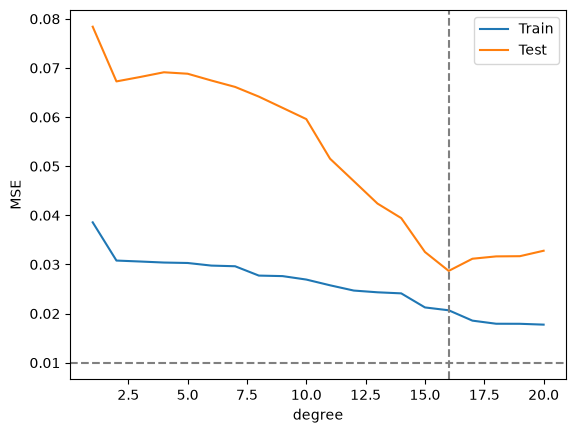

Lowest MSE score of 0.031164989032432405 is for degree 16


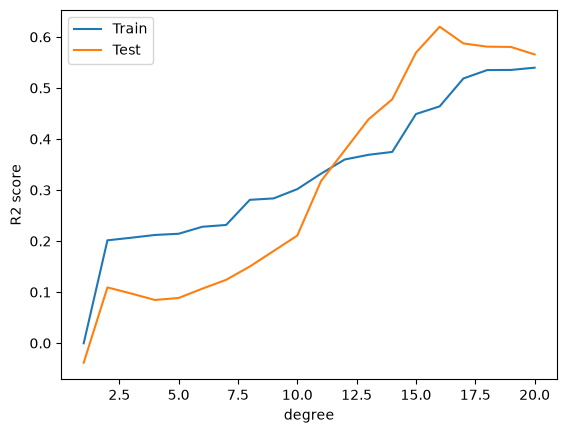

In [140]:
degree = 20
MSE_scores = np.zeros((degree, 2))
r2_scores = np.zeros((degree, 2))
thetas = np.zeros((degree, degree))

x_train, x_test, y_train, y_test = create_dataset()
for d in range(1, degree+1):
    X_train, X_test = create_feature_matrix(x_train, x_test, degree=d)

    theta_train = closed_form(X_train, y_train)

    Y_train = X_train @ theta_train
    Y_test = X_test @ theta_train
    MSE_scores[d-1, :] = [MSE_score(y_train, Y_train), MSE_score(y_test, Y_test)]
    r2_scores[d-1, :] = [r2_score(y_train, Y_train), r2_score(y_test, Y_test)]
    thetas[d-1, -d:degree] = theta_train

min_test_d = np.argmin(MSE_scores[:, 1])+ 1

plt.plot(range(1, d+1), MSE_scores[:, 0], label="Train")
plt.plot(range(1, d+1), MSE_scores[:, 1], label="Test")
plt.axhline(0.1**2, ls='--', color='gray')
plt.axvline(min_test_d, ls='--', color='gray')
# plt.yscale("log")
plt.xlabel("degree")
plt.ylabel(r"MSE")
plt.legend()
plt.show()

print(f"Lowest MSE score of {MSE_scores[min_test_d, 1]} is for degree {min_test_d}")

min_test_d = np.argmin(r2_scores[:, 1])+ 1

plt.plot(range(1, d+1), r2_scores[:, 0], label="Train")
plt.plot(range(1, d+1), r2_scores[:, 1], label="Test")
# plt.axhline(0.1**2, ls='--', color='gray')
# plt.axvline(min_test_d, ls='--', color='gray')
# plt.yscale("log")
plt.xlabel("degree")
plt.ylabel(r"R2 score")
plt.legend()
plt.show()



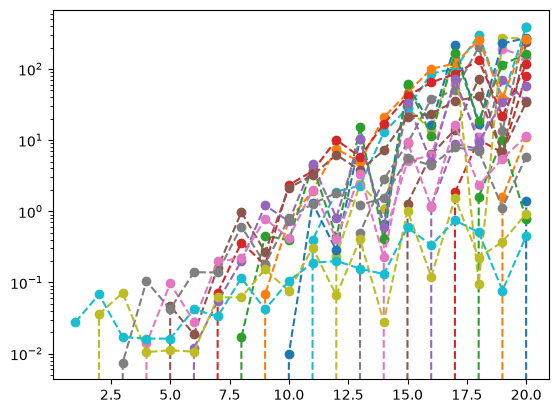

In [150]:
plt.plot(range(1, d+1), np.abs(thetas), 'o--')
plt.yscale("log")
plt.show()

# Part b)

In [128]:
n_lambdas = 100
max_deg = 20
lambdas = np.logspace(-10, 3, n_lambdas)
degrees = np.linspace(1, 20, max_deg)

X, Y = np.meshgrid(degrees, lambdas, indexing='ij')
MSE = np.zeros((2, max_deg, n_lambdas))

for d in range(1, max_deg+1):
    X_train, X_test = create_feature_matrix(x_train, x_test, degree=d)
    for idx, lam in enumerate(lambdas):
        theta_train = closed_form(X_train, y_train, lam=lam)

        Y_train = X_train @ theta_train
        Y_test = X_test @ theta_train
        MSE[:, d-1, idx] = [MSE_score(y_train, Y_train), MSE_score(y_test, Y_test)]


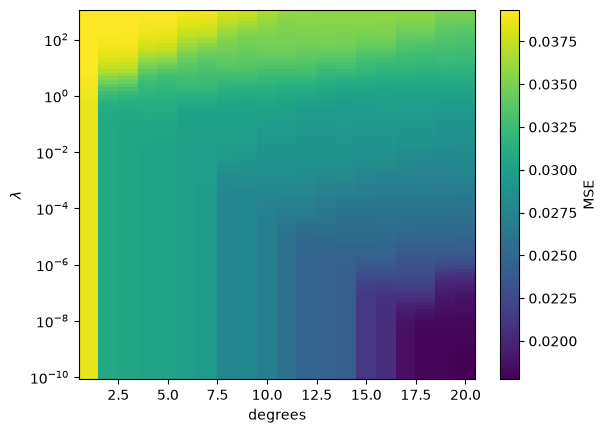

In [129]:
plt.yscale('log')
plt.pcolor(X, Y, MSE[0], shading='auto')
plt.colorbar(label="MSE")
plt.xlabel('degrees')
plt.ylabel(r'$\lambda$')
plt.show()

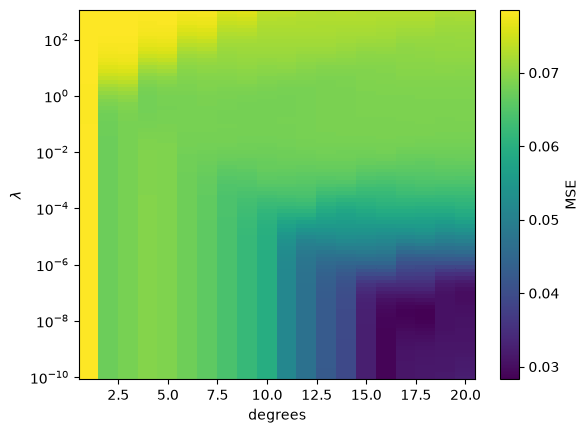

Lowest MSE score of 0.028252975277893614 is for degree 18 with lambda 1.7073526474706922e-08


In [130]:
plt.yscale('log')
plt.pcolor(X, Y, MSE[1], shading='auto')
plt.colorbar(label="MSE")
plt.xlabel('degrees')
plt.ylabel(r'$\lambda$')
plt.show()

index = np.unravel_index(np.argmin(MSE[1]), (max_deg, n_lambdas))

print(f"Lowest MSE score of {MSE[1, index[0], index[1]]} is for degree {index[0]+1} with lambda {lambdas[index[1]]}")

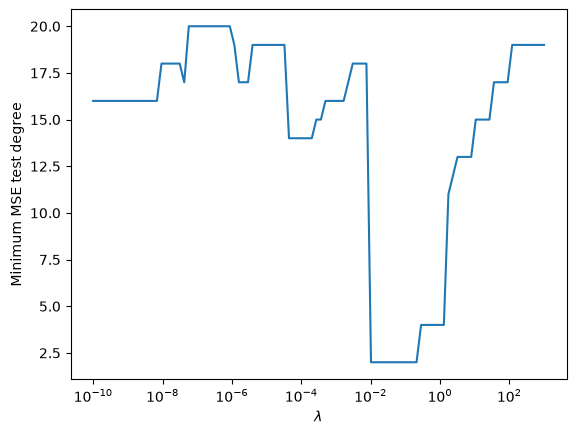

In [131]:
min_test_d = np.argmin(MSE[1], axis=0) + 1
plt.plot(lambdas, min_test_d)
plt.ylabel("Minimum MSE test degree")
plt.xlabel(r"$\lambda$")
plt.xscale("log")
plt.show()